Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("Housing_clean.csv")
df.head()

,house_id,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


Features (X) and Target (y)

In [5]:
X = df[['area', 'bathrooms', 'airconditioning', 'stories']]
y = np.log(df['price'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (436, 4)
Testing set size: (109, 4)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0. ,0.22,0.2 ,0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['area','bathrooms','airconditioning','stories']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.48
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [8]:
y_pred = model.predict(X_test)

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")
print(f"MAE (log scale): {mae:.4f}")

R² Score: 0.5470
RMSE (log scale): 0.2957
MAE (log scale): 0.2393


In [10]:
y_test_actual_price = np.exp(y_test)
y_pred_actual_price = np.exp(y_pred)

rmse_price = np.sqrt(mean_squared_error(y_test_actual_price, y_pred_actual_price))
mae_price = mean_absolute_error(y_test_actual_price, y_pred_actual_price)

print(f"\nRMSE (actual price): ₦{rmse_price:,.2f}")
print(f"MAE (actual price): ₦{mae_price:,.2f}")


RMSE (actual price): ₦1,521,795.53
MAE (actual price): ₦1,140,088.39


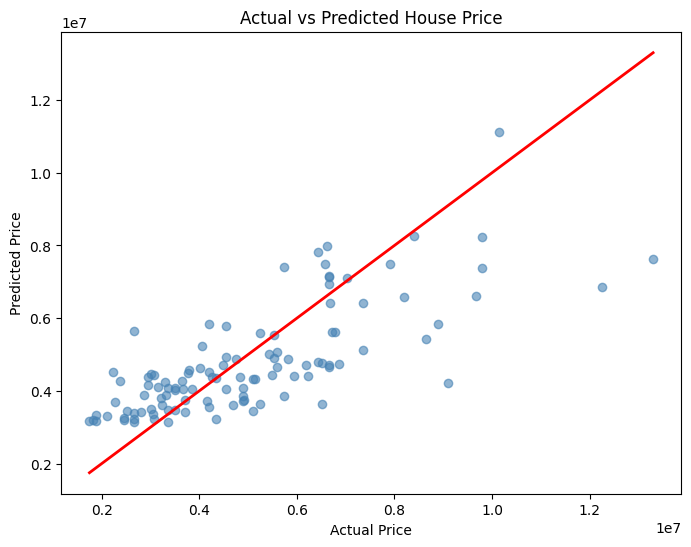

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual_price, y_pred_actual_price, color='steelblue', alpha=0.6)
plt.plot([y_test_actual_price.min(), y_test_actual_price.max()],
         [y_test_actual_price.min(), y_test_actual_price.max()],
         color='red', linewidth=2)
plt.title('Actual vs Predicted House Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

R² Score: 0.5942
RMSE (log scale): 0.2799
MAE (log scale): 0.2217

RMSE (actual price): ₦1,425,286.51
MAE (actual price): ₦1,066,465.21


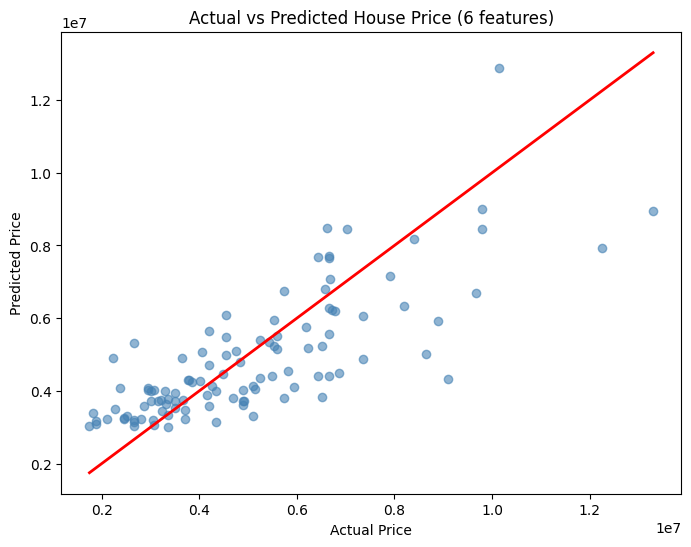

In [13]:
X = df[['area', 'bathrooms', 'airconditioning', 'stories', 'prefarea', 'parking']]
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
mae_log = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")

# Convert back to actual price for interpretability
y_test_actual_price = np.exp(y_test)
y_pred_actual_price = np.exp(y_pred)

rmse_price = np.sqrt(mean_squared_error(y_test_actual_price, y_pred_actual_price))
mae_price = mean_absolute_error(y_test_actual_price, y_pred_actual_price)

print(f"\nRMSE (actual price): ₦{rmse_price:,.2f}")
print(f"MAE (actual price): ₦{mae_price:,.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual_price, y_pred_actual_price, color='steelblue', alpha=0.6)
plt.plot([y_test_actual_price.min(), y_test_actual_price.max()],
         [y_test_actual_price.min(), y_test_actual_price.max()],
         color='red', linewidth=2)
plt.title('Actual vs Predicted House Price (6 features)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

Interpretation (Using the 4 strongest features)

My Linear Regression model, trained using the four strongest predictors from my correlation analysis — Area, Bathrooms, Airconditioning, and Stories — explained about 55% of the variation in house prices, with a typical prediction error of roughly ₦1.52 million.

In practical terms, if I gave this model the physical details of 100 houses, it could account for just over half of why their prices differ from one another using only these four characteristics. The remaining 45% is influenced by factors the model never saw — things like exact location, parking, furnishing, and negotiation, which aren't captured by size and amenities alone.

RMSE specifically punishes large mistakes more heavily than small ones, since it squares each error before averaging. A relatively high RMSE like this tells me the model isn't just slightly off everywhere — it's getting a handful of houses very wrong, which pulls this number up more than a typical, everyday miss would.

This makes sense in the context of a real housing market. Two houses can have identical area, bathrooms, and stories, yet sell for very different prices simply because one sits in a more desirable neighborhood. A model built only on physical specifications will always miss part of the story — and the houses it misses most dramatically are usually the ones driving up an error metric like this.

Interpretation (Adding prefarea and parking)

Adding Prefarea (preferred location) and Parking improved the model meaningfully — R² rose from 55% to 59%, and RMSE dropped by about ₦96,500, from ₦1.52 million to ₦1.43 million. This confirms that location desirability genuinely matters for price, beyond what size and amenities alone can explain — a house in a preferred area commands a premium that physical specifications cannot capture on their own.

However, looking at the actual-vs-predicted plot, the model still struggles in one specific area: luxury houses priced above ₦8 million are consistently under-predicted, in some cases by several million naira. Since RMSE is especially sensitive to large errors like these, the fact that it's still relatively high even after adding two helpful features tells me these luxury houses remain the main source of the model's biggest mistakes. This pattern was present in Model 1 and persists in Model 2, suggesting the issue is not simply a missing feature — it's that the relationship between these features and price may not be a straight line at the luxury end of the market. 

A linear model assumes every extra bathroom or extra story adds the same fixed amount to price regardless of how expensive the house already is, and that assumption appears to break down for the most expensive properties.

Conclusion: Adding location-based features (Prefarea, Parking) provided a real, measurable improvement over the physical-specification-only model, and reduced RMSE accordingly. However, both models share a structural limitation at the high end of the market — visible in the persistently high RMSE driven by a small number of severely mispriced luxury houses — pointing toward the need for a more flexible, non-linear modelling approach in the next iteration.